### Importing Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler

### Loading DataSet

In [32]:
df = pd.read_csv('insurance.csv')

In [33]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [35]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [36]:
df.shape

(1338, 7)

### Checking if there is a need for data cleaning

In [37]:
df.isnull().sum()  # no null values found

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Visuals

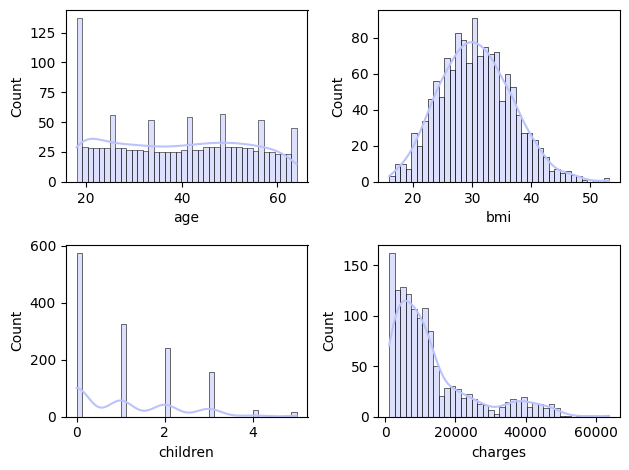

In [38]:
def plotts(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var], kde=True, bins = 40,  color = '#BBC3FC')
    plt.tight_layout()


plotts('age', 1)
plotts('bmi', 2)
plotts('children', 3)
plotts('charges', 4)

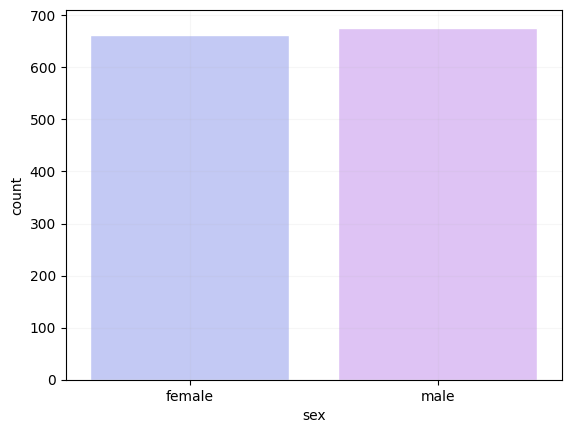

In [39]:
sns.countplot(data = df, x = 'sex', palette=['#BBC3FC','#DFBBFC'], edgecolor = 'white')
plt.grid(True, alpha = 0.1)
plt.show()

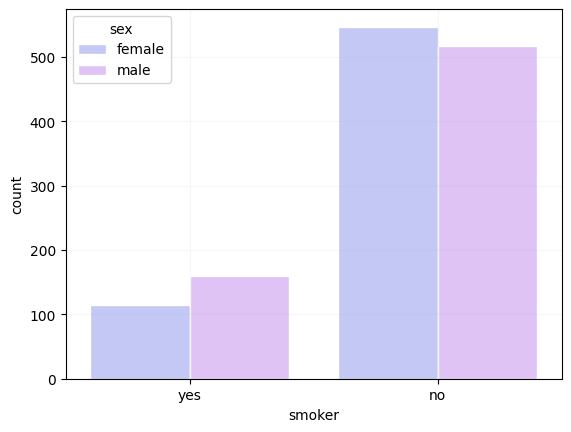

In [40]:
sns.countplot(data=df, x = 'smoker', hue = 'sex', palette=['#BBC3FC','#DFBBFC'], edgecolor = 'white')
plt.grid(True, alpha = 0.1)
plt.show()

In [41]:
numerical_colls = df.select_dtypes(['int64', 'float64'])

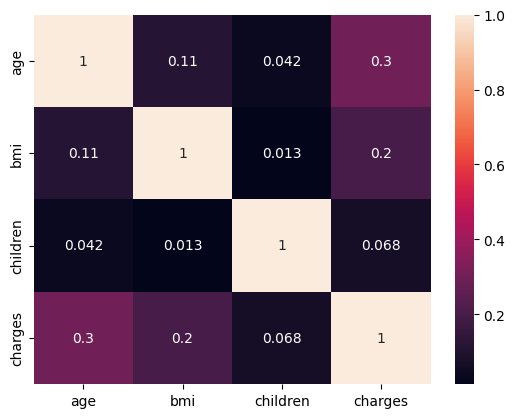

In [42]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

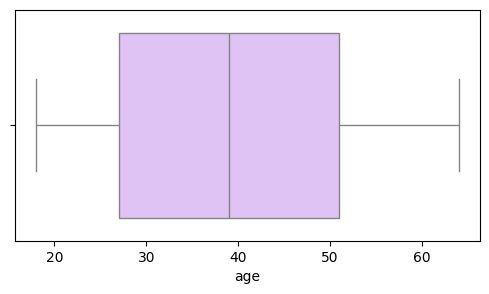

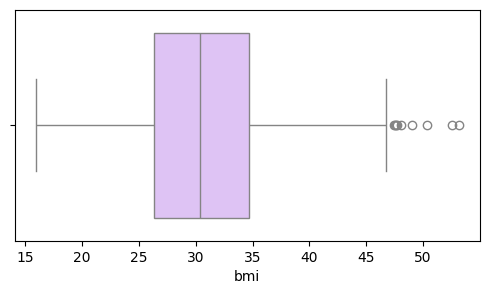

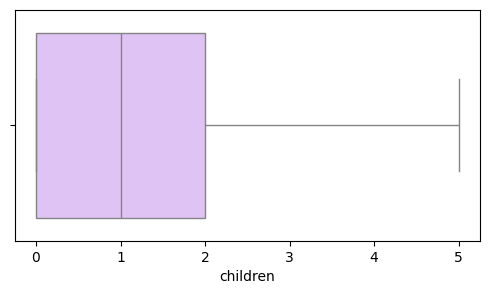

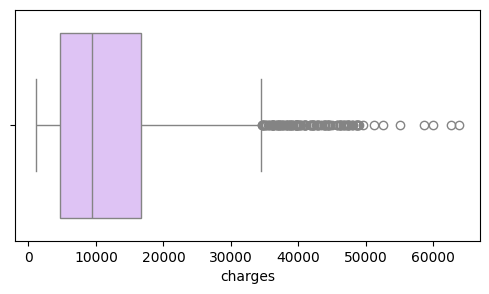

In [43]:
for col in numerical_colls:
    plt.figure(figsize=(6,3))
    sns.boxplot(x = numerical_colls[col], color = '#DFBBFC')

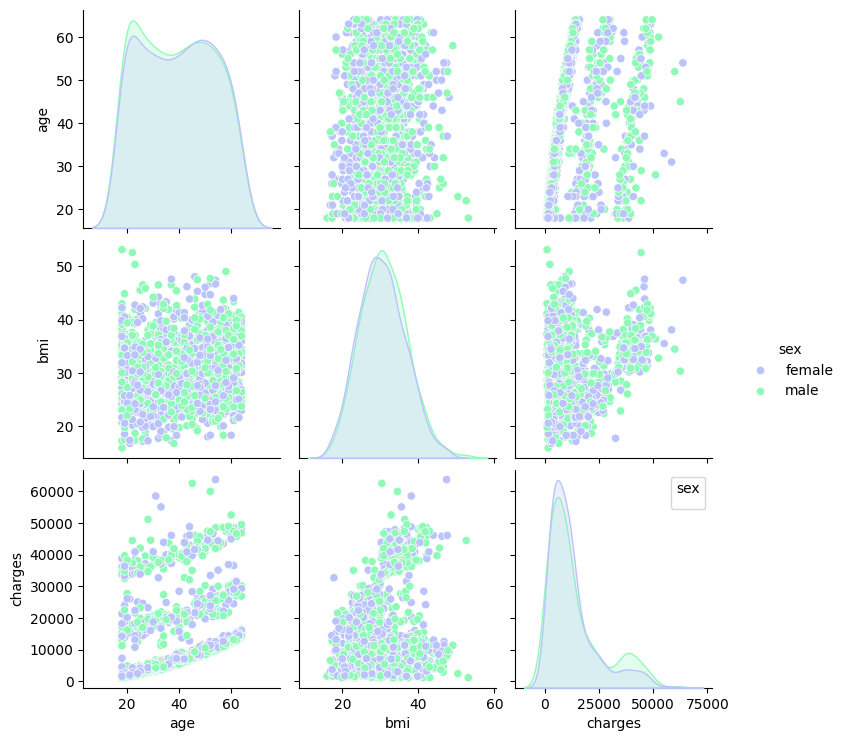

In [44]:
sns.pairplot(df[['age', 'bmi', 'charges', 'sex']],hue = 'sex' , palette=['#BBC3FC','#8FFAB8'])
plt.legend(title = 'sex')
plt.show()

### One-Hot Encoding

In [45]:
df.rename(
    columns={
        'sex' : 'is_male',
        'smoker' : 'is_smoker'
    },
    inplace= True
)

In [46]:
df.head()

,age,is_male,bmi,children,is_smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [47]:
df['is_male'] = df['is_male'].replace({
    'male' : 1,
    'female' : 0
})

df['is_smoker'] = df['is_smoker'].replace({
    'yes' : 1,
    'no' : 0
})

In [48]:
df.head()

,age,is_male,bmi,children,is_smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [49]:
df = pd.get_dummies(data = df , columns=['region'])
df = df.astype('int')

In [50]:
df

,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27,0,1,16884,0,0,0,1
1,18,1,33,1,0,1725,0,0,1,0
2,28,1,33,3,0,4449,0,0,1,0
3,33,1,22,0,0,21984,0,1,0,0
4,32,1,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30,3,0,10600,0,1,0,0
1334,18,0,31,0,0,2205,1,0,0,0
1335,18,0,36,0,0,1629,0,0,1,0
1336,21,0,25,0,0,2007,0,0,0,1


In [51]:
df['bmi_category'] = pd.cut(
    df['bmi'],                     
    bins = [0, 18.5, 25, 30, 100],
    labels = ['Underweight', 'Normal', 'Overweight', 'Obese'])

In [52]:
df = pd.get_dummies(data=df, columns=['bmi_category'])
df = df.astype('int')

In [53]:
df = df.drop('bmi', axis = 1)

In [54]:
df.head()

,age,is_male,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,0,0,1,16884,0,0,0,1,0,0,1,0
1,18,1,1,0,1725,0,0,1,0,0,0,0,1
2,28,1,3,0,4449,0,0,1,0,0,0,0,1
3,33,1,0,0,21984,0,1,0,0,0,1,0,0
4,32,1,0,0,3866,0,1,0,0,0,0,1,0


### Standard-Scaling

In [55]:
colls = ['age', 'children']

In [56]:
scalar = StandardScaler()

df[colls] = scalar.fit_transform(df[colls])

In [57]:
df

,age,is_male,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.438764,0,-0.908614,1,16884,0,0,0,1,0,0,1,0
1,-1.509965,1,-0.078767,0,1725,0,0,1,0,0,0,0,1
2,-0.797954,1,1.580926,0,4449,0,0,1,0,0,0,0,1
3,-0.441948,1,-0.908614,0,21984,0,1,0,0,0,1,0,0
4,-0.513149,1,-0.908614,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,1,1.580926,0,10600,0,1,0,0,0,0,1,0
1334,-1.509965,0,-0.908614,0,2205,1,0,0,0,0,0,0,1
1335,-1.509965,0,-0.908614,0,1629,0,0,1,0,0,0,0,1
1336,-1.296362,0,-0.908614,0,2007,0,0,0,1,0,1,0,0


In [58]:
df = df.drop(columns=['region_northeast', 'bmi_category_Normal'])

In [59]:
df.head()

,age,is_male,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Overweight,bmi_category_Obese
0,-1.438764,0,-0.908614,1,16884,0,0,1,0,1,0
1,-1.509965,1,-0.078767,0,1725,0,1,0,0,0,1
2,-0.797954,1,1.580926,0,4449,0,1,0,0,0,1
3,-0.441948,1,-0.908614,0,21984,1,0,0,0,0,0
4,-0.513149,1,-0.908614,0,3866,1,0,0,0,1,0
